In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df=pd.read_csv("Social_Network_Ads.csv")
df=pd.get_dummies(df,drop_first=True)

In [3]:
indep = df.drop('Purchased', axis=1)
dep = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size=0.3, random_state=0)

In [4]:
param_grid = {'n_neighbors': range(1, 31), 'metric': ['euclidean', 'manhattan', 'minkowski']}
gsv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
gsv.fit(X_train, y_train)
gsv.best_params_

{'metric': 'manhattan', 'n_neighbors': 13}

              precision    recall  f1-score   support

           0       0.77      0.90      0.83        79
           1       0.71      0.49      0.58        41

    accuracy                           0.76       120
   macro avg       0.74      0.69      0.71       120
weighted avg       0.75      0.76      0.74       120



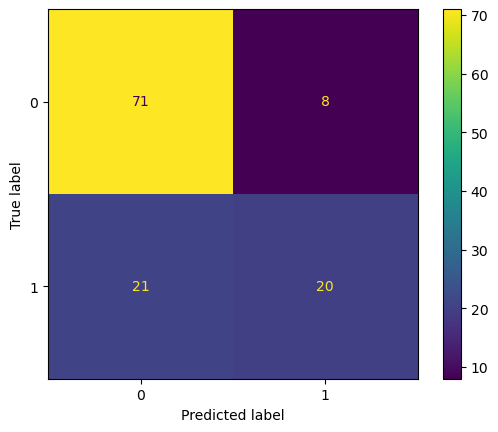

In [7]:
knn = KNeighborsClassifier(**gsv.best_params_)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()